UG Pipeline

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [2]:
# 1. Carga de datos (ajusta el nombre del archivo según el de Kaggle)
df = pd.read_csv('data/Ultimate_Games_Dataset.csv')

In [3]:
print(df.columns.tolist())

['serial_no', 'game_id', 'title', 'release_date', 'release_year', 'all_genres', 'theme', 'art_style', 'view_dimension', 'game_mode', 'is_multiplayer', 'controls', 'developers', 'publishers', 'all_platforms', 'platform_count', 'esrb_rating', 'user_rating', 'metacritic', 'ratings_count', 'reviews_count', 'library_count', 'avg_playtime_hours', 'achievements_count', 'game_series_count', 'status_owned', 'status_beaten', 'status_playing', 'status_dropped', 'status_toplay', 'status_yet', 'all_tags', 'available_stores', 'cover_image_url', 'official_website', 'url_slug', 'description_clean', 'popularity_score', 'engagement_score', 'decade', 'is_multi_platform', 'rating_tier', 'metacritic_tier']


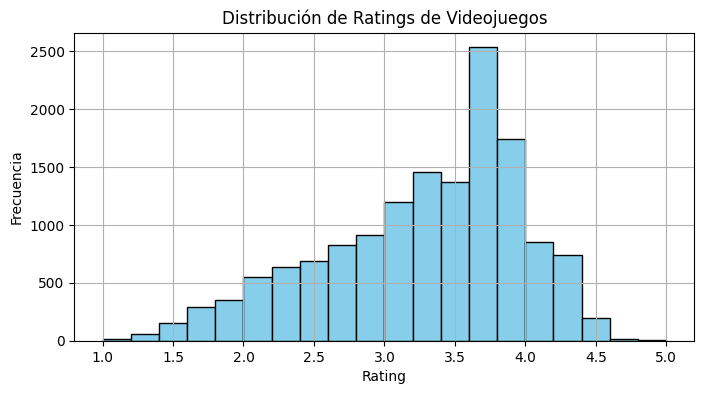

In [4]:
# --- HISTOGRAMA ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['user_rating'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Ratings de Videojuegos')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()
# -----------------------------

In [5]:
# 2. Separación de características
target = 'user_rating'

# Lista completa de columnas que estorban o rompen el modelo
cols_to_drop = [
    target, 'serial_no', 'game_id', 'title', 'release_date',
    'all_genres', 'theme', 'art_style', 'view_dimension', 
    'game_mode', 'controls', 'developers', 'publishers', 
    'all_platforms', 'all_tags', 'available_stores', 
    'cover_image_url', 'official_website', 'url_slug', 
    'description_clean', 'rating_tier', 'metacritic_tier'
]

# Creamos X solo con columnas numéricas y categorías simples
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
y = df[target]

# Eliminamos filas donde el target sea nulo (importante para el fit)
if y.isnull().any():
    mask = y.notnull()
    X = X[mask]
    y = y[mask]

In [6]:
# 3. Selección automática de columnas por tipo
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [7]:
# 4. Definición de transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [8]:
# 5. ColumnTransformer: El corazón del Feature Engineering
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [9]:
# 6. Pipeline completo
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

Optimización con GridSearchCV

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

In [11]:
# 7. Dividir los datos: 80% para entrenar y 20% para evaluar al final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de prueba: {X_test.shape[0]} filas")

Datos de entrenamiento: 11690 filas
Datos de prueba: 2923 filas


In [12]:
# 8. Optimización de hiperparámetros con GridSearchCV
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, 
                           scoring='neg_mean_absolute_error', n_jobs=-1)

# Entrenamos (esto aplica automáticamente el ColumnTransformer a cada split)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Mejores parámetros encontrados: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}


In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

In [14]:
# 9. Usamos el mejor modelo que encontró el GridSearch automáticamente
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [15]:
# 10. Reporte de métricas
print("--- Evaluación del Modelo ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

--- Evaluación del Modelo ---
MAE: 0.0613
R2 Score: 0.9600


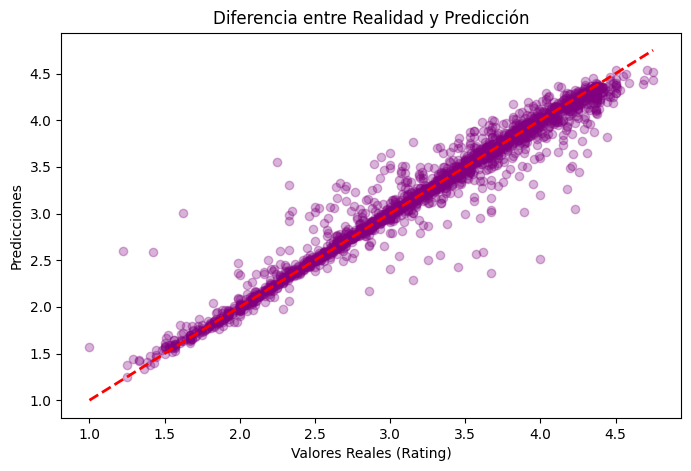

In [16]:
# 11. Gráfica de Predicción vs Realidad
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (Rating)')
plt.ylabel('Predicciones')
plt.title('Diferencia entre Realidad y Predicción')
plt.show()

Exportación del Archivo .pkl

In [20]:
# Guardar la carpeta en models
import joblib
import os

# 1. Aseguramos que la carpeta exista y sino, la crea
os.makedirs('models', exist_ok=True)

# 2. Guardar el mejor modelo (best_model o grid_search.best_estimator_)
joblib.dump(grid_search.best_estimator_, 'models/pipeline_final.pkl')

print("Archivo 'pipeline_final.pkl' generado con éxito en la carpeta /models.")

Archivo 'pipeline_final.pkl' generado con éxito en la carpeta /models.


In [21]:
import os
print(os.listdir('models'))

['pipeline_final.pkl']


Prueba de modelo

In [22]:
# Cargar el modelo guardado
modelo_cargado = joblib.load('models/pipeline_final.pkl')

# Usar una fila de X_test como ejemplo
ejemplo = X_test.iloc[[0]]
prediccion = modelo_cargado.predict(ejemplo)

print(f"Valor real: {y_test.iloc[0]}")
print(f"Predicción del modelo cargado: {prediccion[0]}")

Valor real: 3.78
Predicción del modelo cargado: 3.758237662337658
